In [1]:
import torch
# torch.autograd.set_detect_anomaly(True)
from torch.utils.data import DataLoader,WeightedRandomSampler
from torch.optim.lr_scheduler import PolynomialLR
import torch.nn.functional as F
from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from tqdm.notebook import tqdm
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
import os
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import (
    plot_some_images ,read_images ,
    pre_hard_skeletonize , pre_soft_skeletonize,
    compute_confution_matrix,draw_mask,TP_TN_FP_FN,)
from utils.preprocessing import (
    WhiteTopHat , CLAHE , normalize_xca,
    BrightnessMultiplicativeNNUNet2D,
    ContrastAugmentationNNUNet2D)
from utils.dataset import  (
    TrainUnetDataset  
)
from models.nnunet import nnUnet
from models.memory_unet import MemoryUnet
from utils.losses import UnetLoss
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###
from trainer import evaluation

In [ ]:
args = {
    "base_path" : "./dataset/syntax/",
    "memory_unet":{
        "layer_count":4,
        "channel_max":256,
        "downsampling":"maxpool",
        "dropout" : False,
        "normaliztion":"InstanceNorm2d",#InstanceNorm2d
        "activation" : "LeakyReLU",
        "first_layer_out_c" : 64,
        "deep_super_vision":True
    },
    "image_shape" : (448,448),
    "in_c":1,
    
    "training_mode":"binary",
    "report_class_wise":True,
    "attention" : False,
    "batch_size" : 8,
    "num_workers" : 5,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "epcohs":10,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "loss_type":"tversky",
    "output_base_path" : "./outputs",
    "name" : "binary-tests-dsv",
    "deep_super_vision" : False,
    "mask_ce_weights":None,
    "layer_count":5,
    ### Loss Functions
    "mask_ce_conf":{
        "imp_coef":1.0
    },
    "focal_ce_conf":{
        "gamma":2.0,
        "loss_scale":1.0,
        "imp_coef":1.0
    },
    "tversky_conf":{
        "alpha":0.9,
        "beta":0.1,
        "gamma":2.00,
        "weights":None,
        "imp_coef":1.0
    },
    "cl_dice_conf":{
        "imp_coef":1.0,
        "k":40
    },
    ### Optimizers
    "sgd_conf":{
        "lr" : 0.1,
        "momentum" : 0.99,
        "weight_decay" : 3e-5,
        "nesterov":True
    },
    "adam_conf":{
        "lr" : 0.01,
        "weight_decay" : 3e-5,
    }
}
if(args["training_mode"] == "binary"):
    args["class_count"] = 2 
    class_map = {
        1:"fg"
    }

else:
    args["class_count"] = 26
    class_map = {
        1: '1',2: '2', 3: '3',4: '4',
        5: '5',6: '6',7:'9',8:'7',9:'9a',
        10:'10',11:'8',12:'10a',13:'12',14:'11',
        15:'12a',16:'12b',17:'13',18:'14',19:'14a',
        20:'14b',21:'15',22:'16',
        23: '16a',24: '16b',25: '16c',
    }

# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","mask CE-Loss",args["loss_type"],"cl dice loss"]
if(args["memory_unet"]["deep_super_vision"]):
    shape = args["image_shape"]
    loss_weights = [1/(2**i) for i in range(1,args["layer_count"])]
else:
    loss_weights = []
loss_weights



[0.5, 0.25, 0.125, 0.0625]

In [3]:
if(args["training_mode"]!="binary"):
    b=0.999

    train_class_counts = [
        1200,374,375,369,303,525,537,
        198,340,70,21,310,1,61,320,129,
        63,305,107,49,127,38,232,43,48,31
    ]

    total = np.sum(train_class_counts)
    mask_ce_weights = np.log(total/np.array(train_class_counts))
    mask_ce_weights = (mask_ce_weights / mask_ce_weights.mean()).tolist()
    mask_ce_weights[0]=0.1

    args["mask_ce_weights"]=mask_ce_weights
    args["mask_ce_weights"]
else:
    args["mask_ce_weights"]=[0.1,1]

In [4]:
# args["t_alpha"] = [1,0.8]
args["tversky_conf"]["t_alpha"] = None

In [5]:
train_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    A.Downscale(
        scale_range=[0.7, 1],
        interpolation_pair={"downscale": 0, "upscale": 0},
        p=0.5
    ),
    A.GaussNoise(
        std_range=[0.0, 0.1],
        mean_range=[0, 0],
        per_channel=True,
        noise_scale_factor=1,
        p=0.5
    ),
    A.GaussianBlur(
        sigma_limit=[1.0,1.5],
        blur_limit = (3,7),
        p=0.5
    ),

    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.5),
    A.Compose([
        A.InvertImg(p=1.0),
        A.RandomGamma(gamma_limit=(70, 150), p=1.0),
        A.InvertImg(p=1.0),
    ], p=0.5),
    BrightnessMultiplicativeNNUNet2D(multiplier_range=(0.70, 1.3), p=0.5),
    ContrastAugmentationNNUNet2D(contrast_range=(0.65, 1.5), p=0.5),
    A.RandomGamma(
        gamma_limit=(90, 120), 
        p=0.5
    ),
    A.Affine(
        scale=(0.7, 1.4),  
        translate_percent=(0, 0),
        rotate=0,               
        shear=0,                 
        fit_output=False, 
        p=0.5
    ),
    A.Rotate(limit=30, p=0.5, fill_mask = 0),
    A.Rotate(limit=-30, p=0.5, fill_mask = 0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    ]
)
test_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    ]  
)

if(args["in_c"]==1):
    normalizer = normalize_xca
else:
    normalizer = A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
    )
train_preprocess = None


/home/parsa/Masters/Coronary Artry/Datasets/Arcade/codes/utils/preprocessing.py:50: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/home/parsa/Masters/Coronary Artry/Datasets/Arcade/codes/utils/preprocessing.py:63: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


In [6]:
train_images = read_images(base_path = args["base_path"],preprocessor = train_preprocess,part = "train",chosen_labels=[19,25])
valid_images = read_images(base_path = args["base_path"],preprocessor = train_preprocess,part = "val",chosen_labels=[19,25])


NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

In [7]:

train_ds = TrainUnetDataset(
    transform = train_transforms,
    data = train_images , 
    normalizer = normalizer,
    example_phase=False
)
valid_ds = TrainUnetDataset(
    transform = test_transforms,
    data = valid_images,
    normalizer = normalizer,
    example_phase=False
)
# sampler = WeightedRandomSampler(
#     weights=sampler_weights, 
#     num_samples=len(sampler_weights),
#     replacement=True)

train_loader = DataLoader(
    train_ds,
    batch_size = args["batch_size"] ,
    num_workers = args["num_workers"] ,
    pin_memory=True,
    shuffle=True,

    # sampler=sampler
)
valid_loader = DataLoader(
    valid_ds,
    batch_size = args["batch_size"]  ,
    num_workers = args["num_workers"] ,
    pin_memory=True,
    shuffle=False,

)


In [ ]:

# model = nnUnet(args).to(args["device"])
model = MemoryUnet(args).to(args["device"])

loss_fn = UnetLoss(args)
# optimizer = torch.optim.Adam(
#     model.parameters(), 
#     **args["adam_conf"]
# )
optimizer = torch.optim.SGD(
    model.parameters(),
    **args["sgd_conf"]
)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
# lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
lr_sch = None
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map,class_count=args["class_count"]-1)


best_model = trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)
# best_model = model


encoder info : 
[1, 64, 128, 256, 256]
-----------------------
loss is set to tversky


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

--- Total Norm ---
tensor(0.9277, device='cuda:0')
----------------------

current lr : 0.1
train ==> epcoh (0)
total loss : 1.8966369647979737 - mask CE-Loss : 0.6003192718029022 - tversky : 0.5640114356279373
cl dice loss : 0.7323062541484833 - 
train avg metrics for epoch 0 :
avg dice : 0.43549636006355286 - avg precision : 0.3395325839519501 - avg recall : 0.6070778965950012
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 0.8985709023475646 - mask CE-Loss : 0.36555618345737456 - tversky : 0.17817656427621842
cl dice loss : 0.3548381638526916 - 
valid avg metrics for epoch 0 :
avg dice : 0.6422027349472046 - avg precision : 0.6234658360481262 - avg recall : 0.6621006727218628
fg => dice : 0.6422027349472046 p : 0.6234658360481262 , r : 0.6621006727218628
------------------------------------------------------------
New Best! : dice = 0.6422027349472046


  0%|          | 0/125 [00:00<?, ?it/s]

current lr : 0.1
train ==> epcoh (1)
total loss : 1.3179256100654602 - mask CE-Loss : 0.44325499749183656 - tversky : 0.33534515702724454
cl dice loss : 0.5393254463672638 - 
train avg metrics for epoch 1 :
avg dice : 0.6208895444869995 - avg precision : 0.5563554167747498 - avg recall : 0.7023592591285706
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (1)
total loss : 0.9213901042938233 - mask CE-Loss : 0.417315092086792 - tversky : 0.1430597162246704
cl dice loss : 0.3610152983665466 - 
valid avg metrics for epoch 1 :
avg dice : 0.641443133354187 - avg precision : 0.6949833035469055 - avg recall : 0.595562219619751
fg => dice : 0.641443133354187 p : 0.6949833035469055 , r : 0.595562219619751
------------------------------------------------------------


  0%|          | 0/125 [00:00<?, ?it/s]

current lr : 0.1
train ==> epcoh (2)
total loss : 1.2180318179130554 - mask CE-Loss : 0.4125268815755844 - tversky : 0.3033104727268219
cl dice loss : 0.5021944642066956 - 
train avg metrics for epoch 2 :
avg dice : 0.6424764394760132 - avg precision : 0.578914999961853 - avg recall : 0.7217167019844055
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (2)
total loss : 0.7554551339149476 - mask CE-Loss : 0.3034496462345123 - tversky : 0.13196013748645782
cl dice loss : 0.3200453495979309 - 
valid avg metrics for epoch 2 :
avg dice : 0.6855797171592712 - avg precision : 0.7155624628067017 - avg recall : 0.6580084562301636
fg => dice : 0.6855797171592712 p : 0.7155624628067017 , r : 0.6580084562301636
------------------------------------------------------------
New Best! : dice = 0.6855797171592712


  0%|          | 0/125 [00:00<?, ?it/s]

Save Model
Saving Memory
Saving All Plots


  0%|          | 0/25 [00:00<?, ?it/s]

Saving Examples


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

...

Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 12/12 [00:00<00:00, 2431.60it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./models/swin_encoder.py
processing ./models/swin_blocks.py
processing ./models/conv_lstm.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  5.30it/s]


processing ./temp_script.py


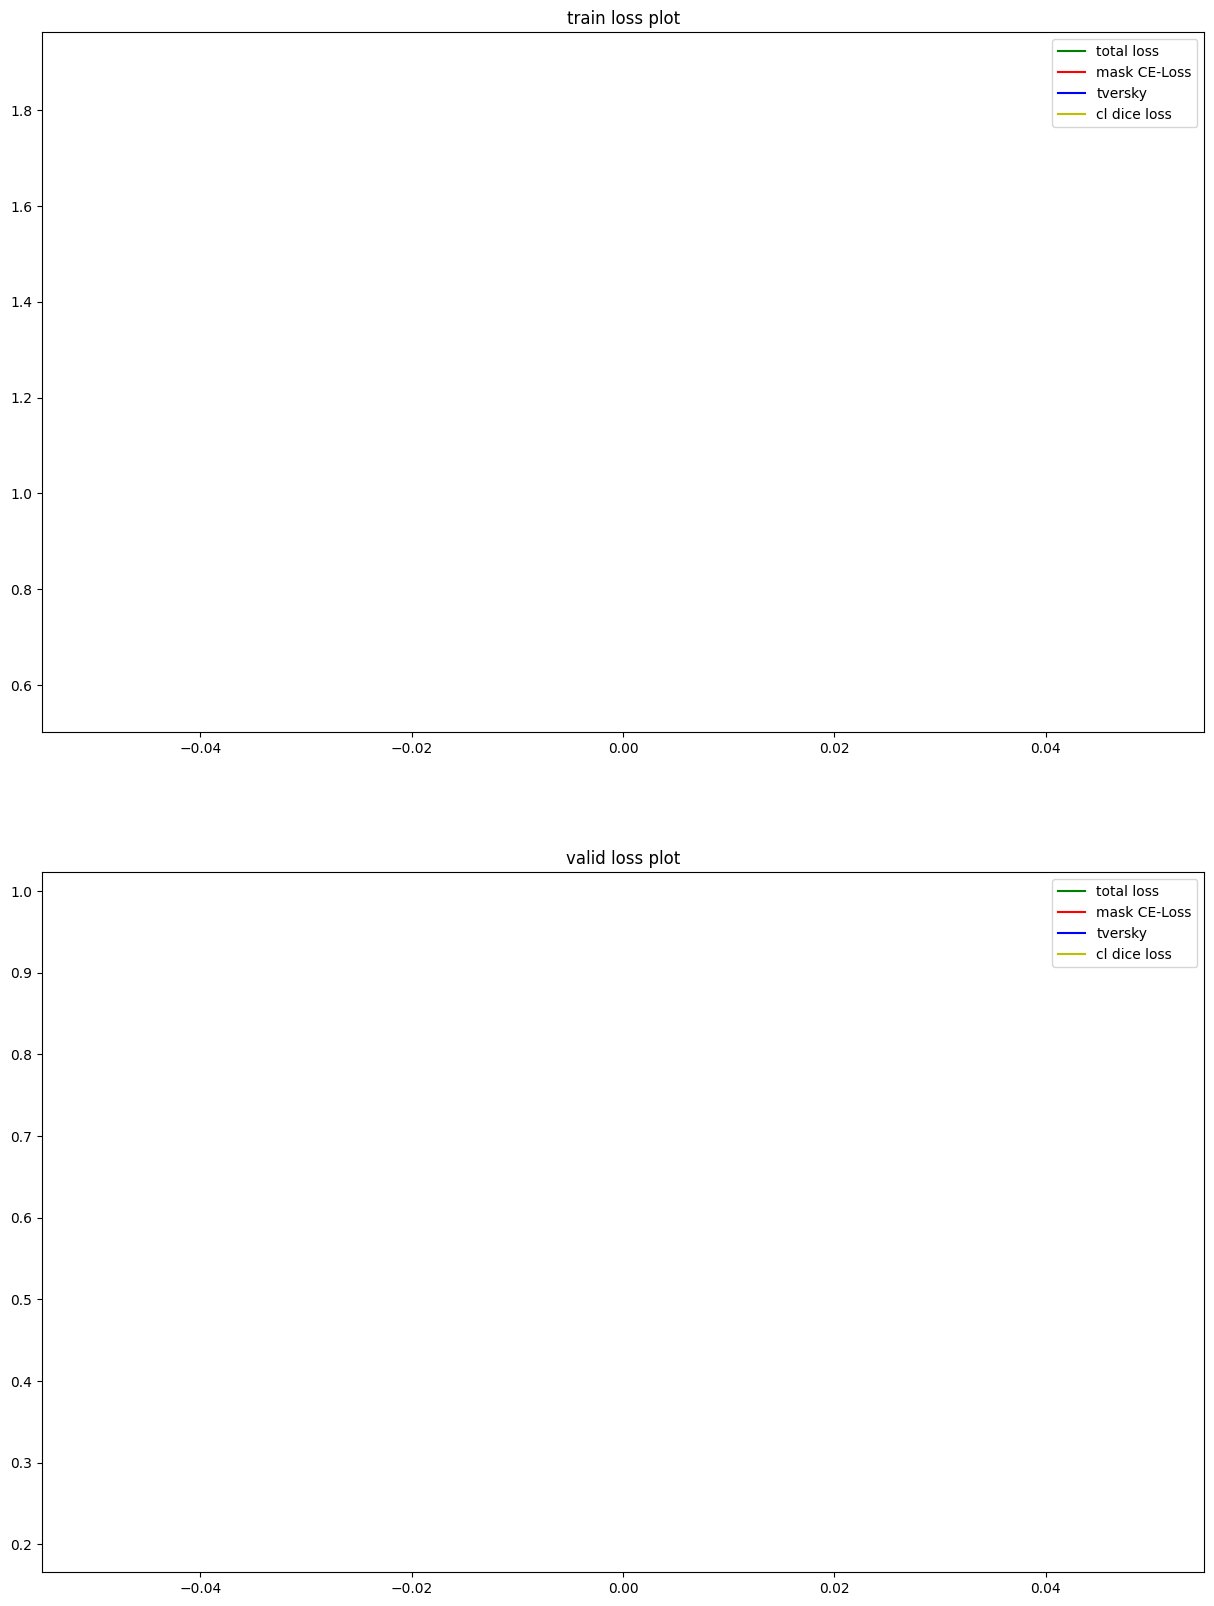

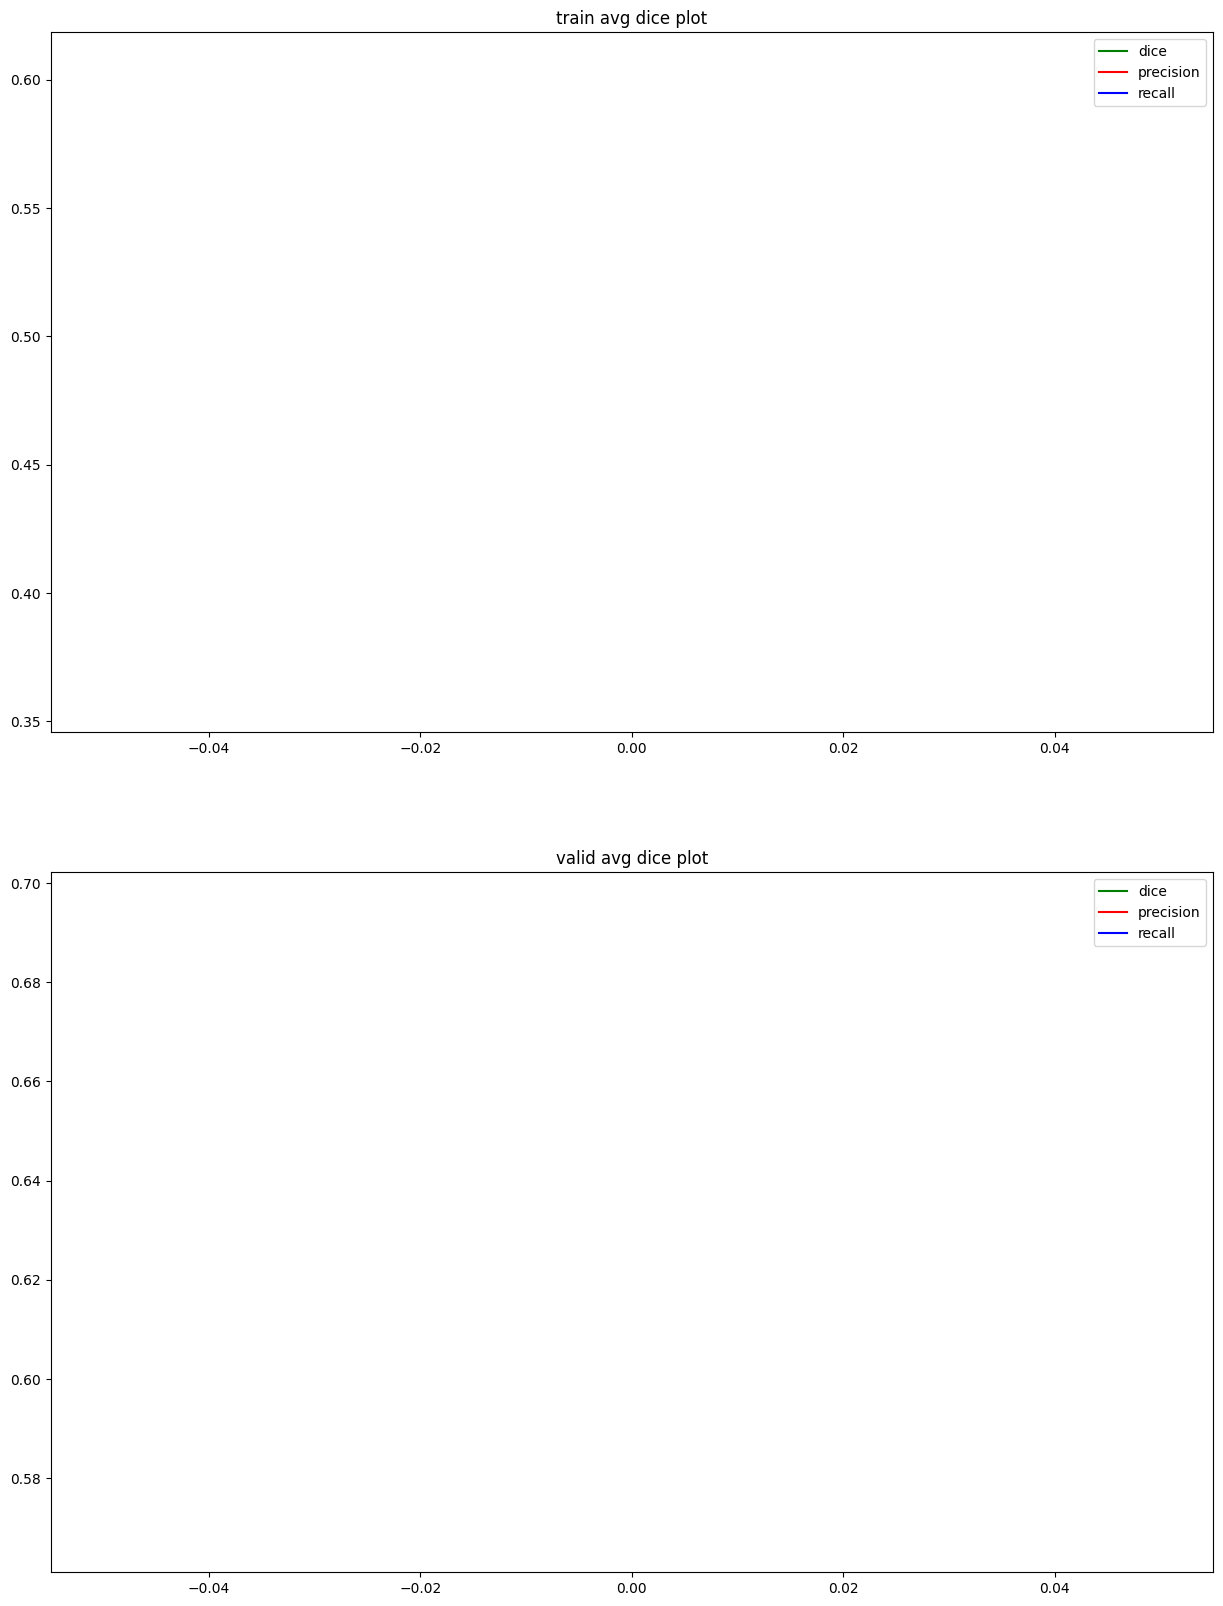

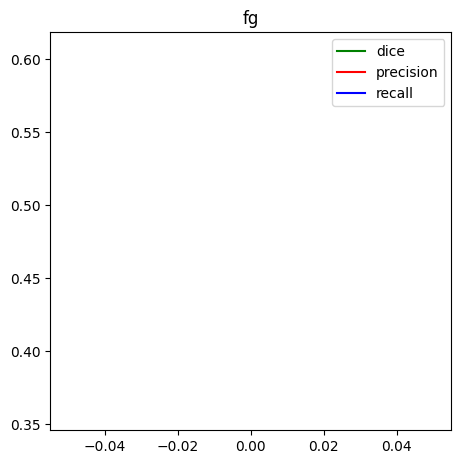

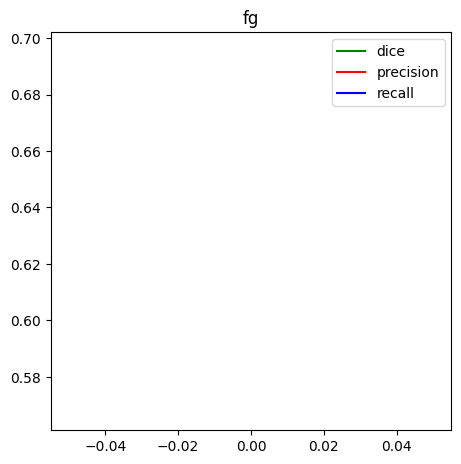

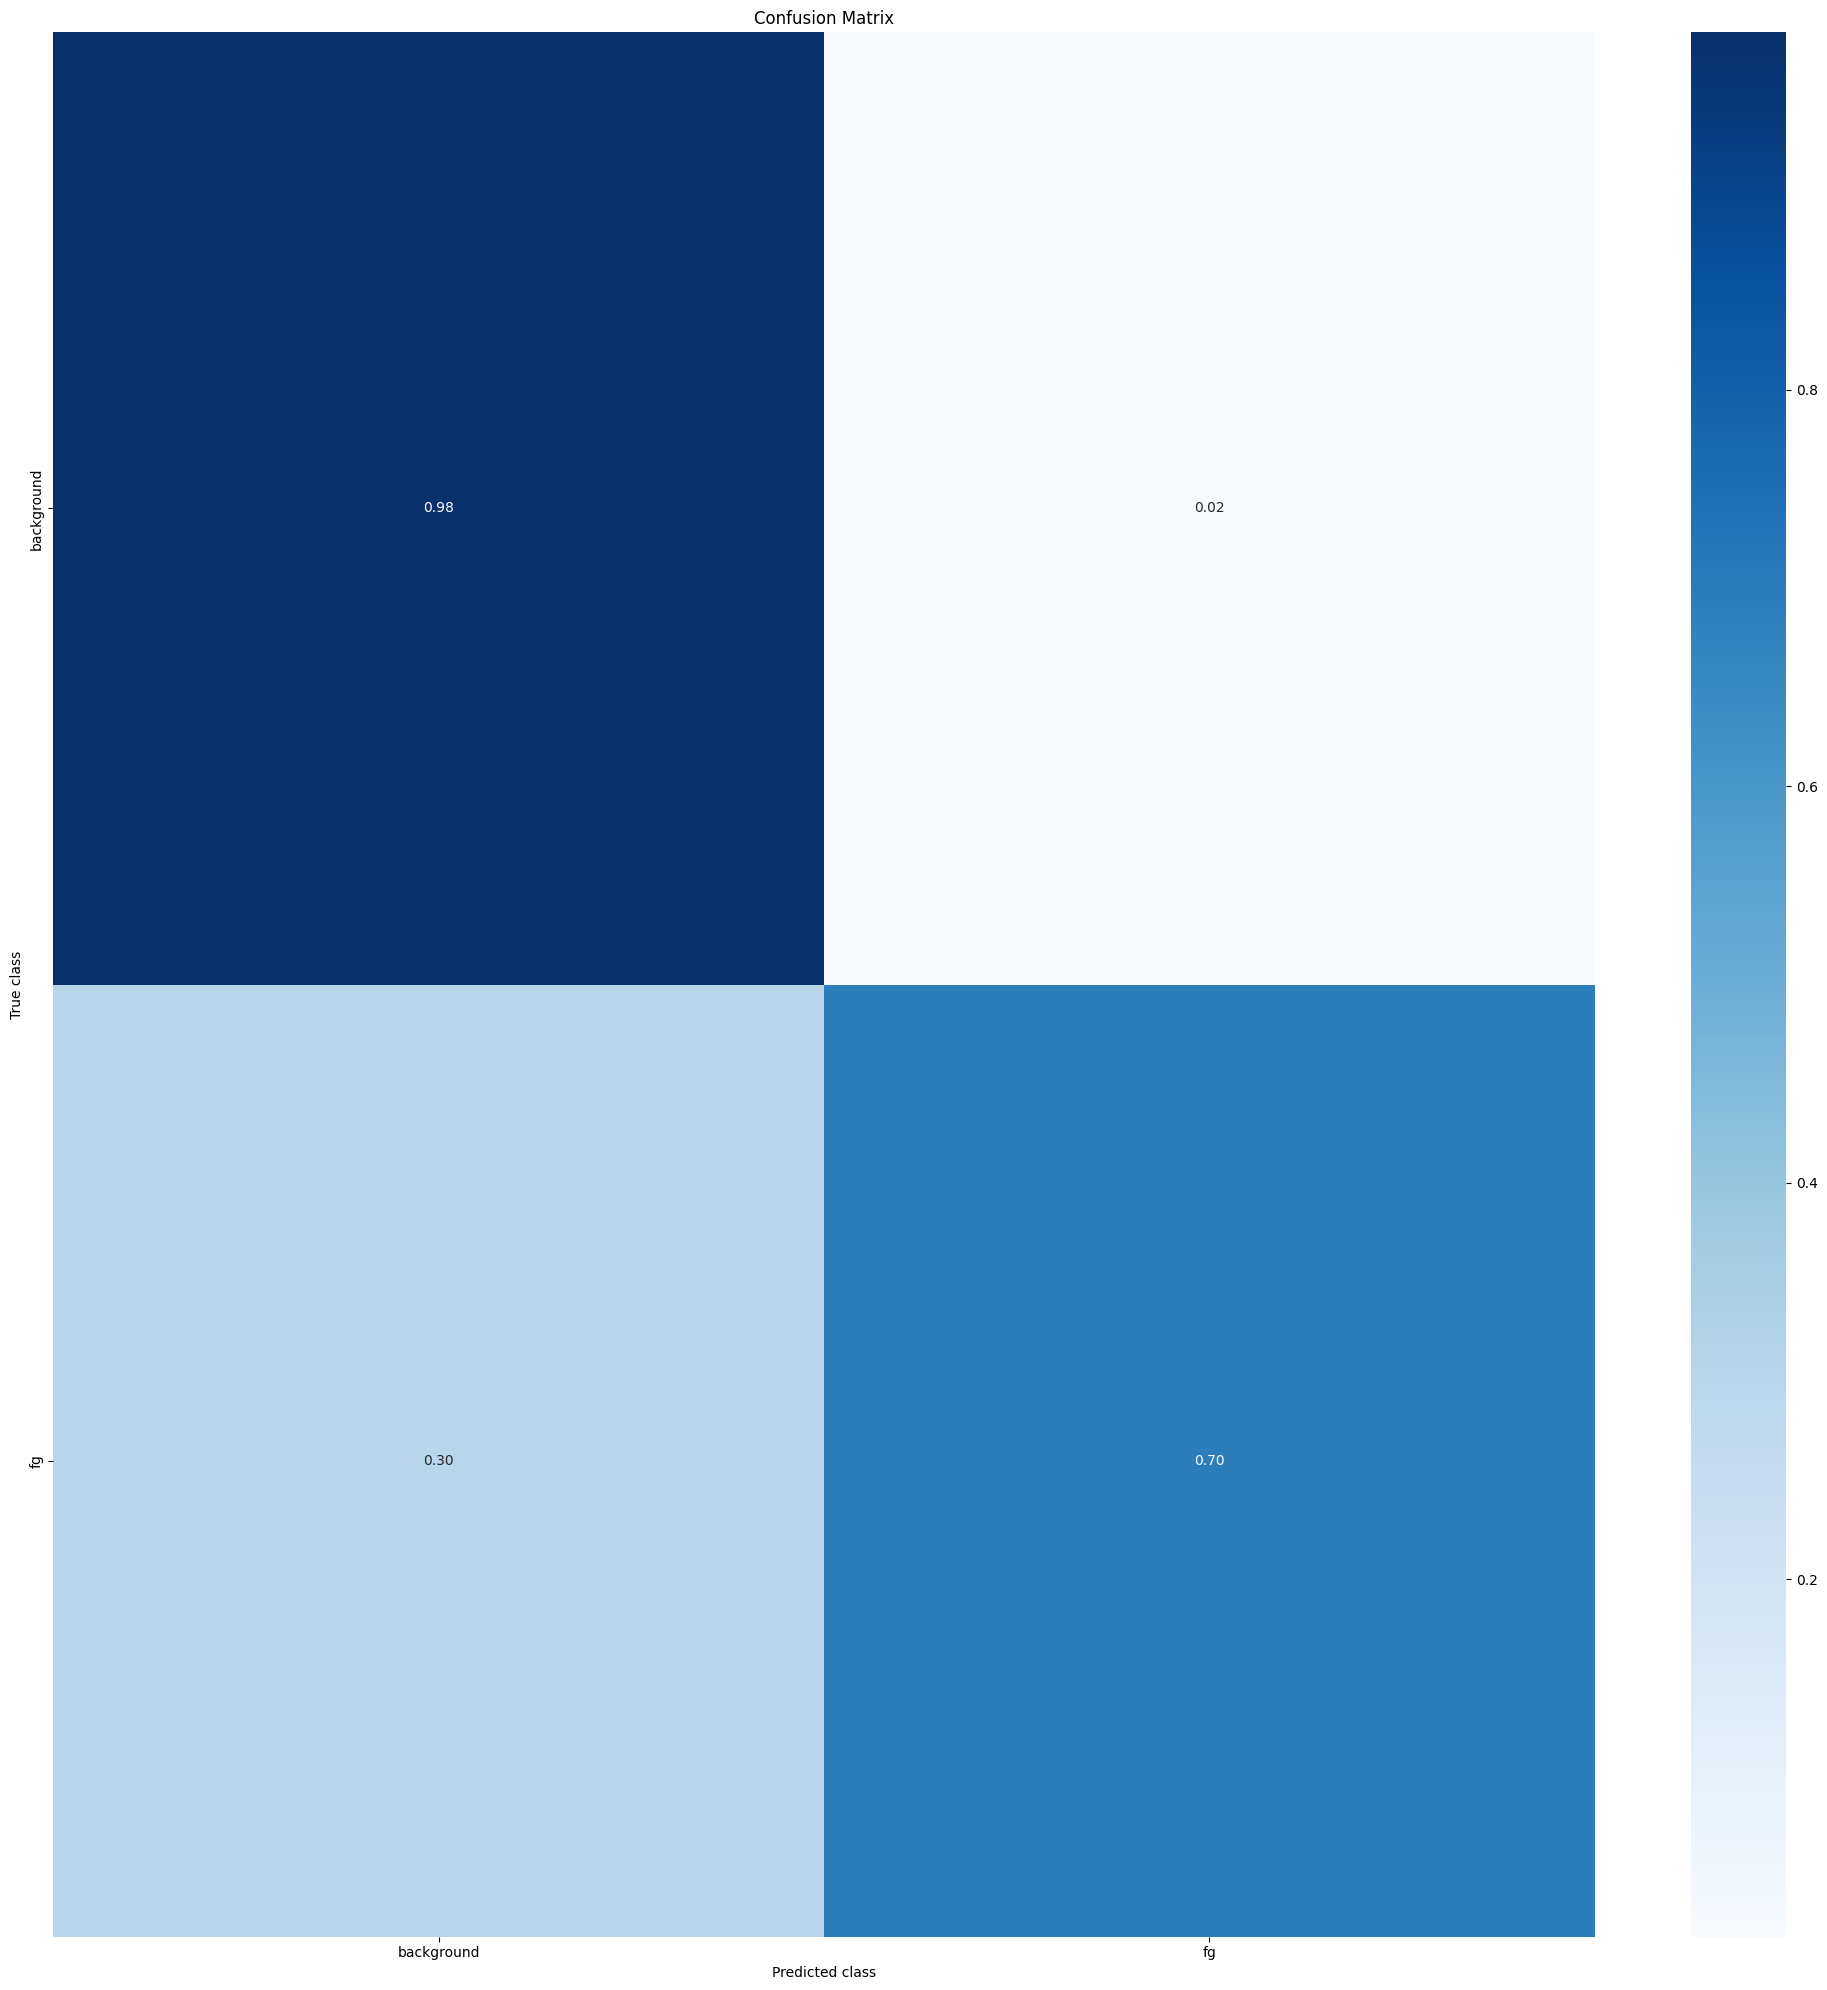

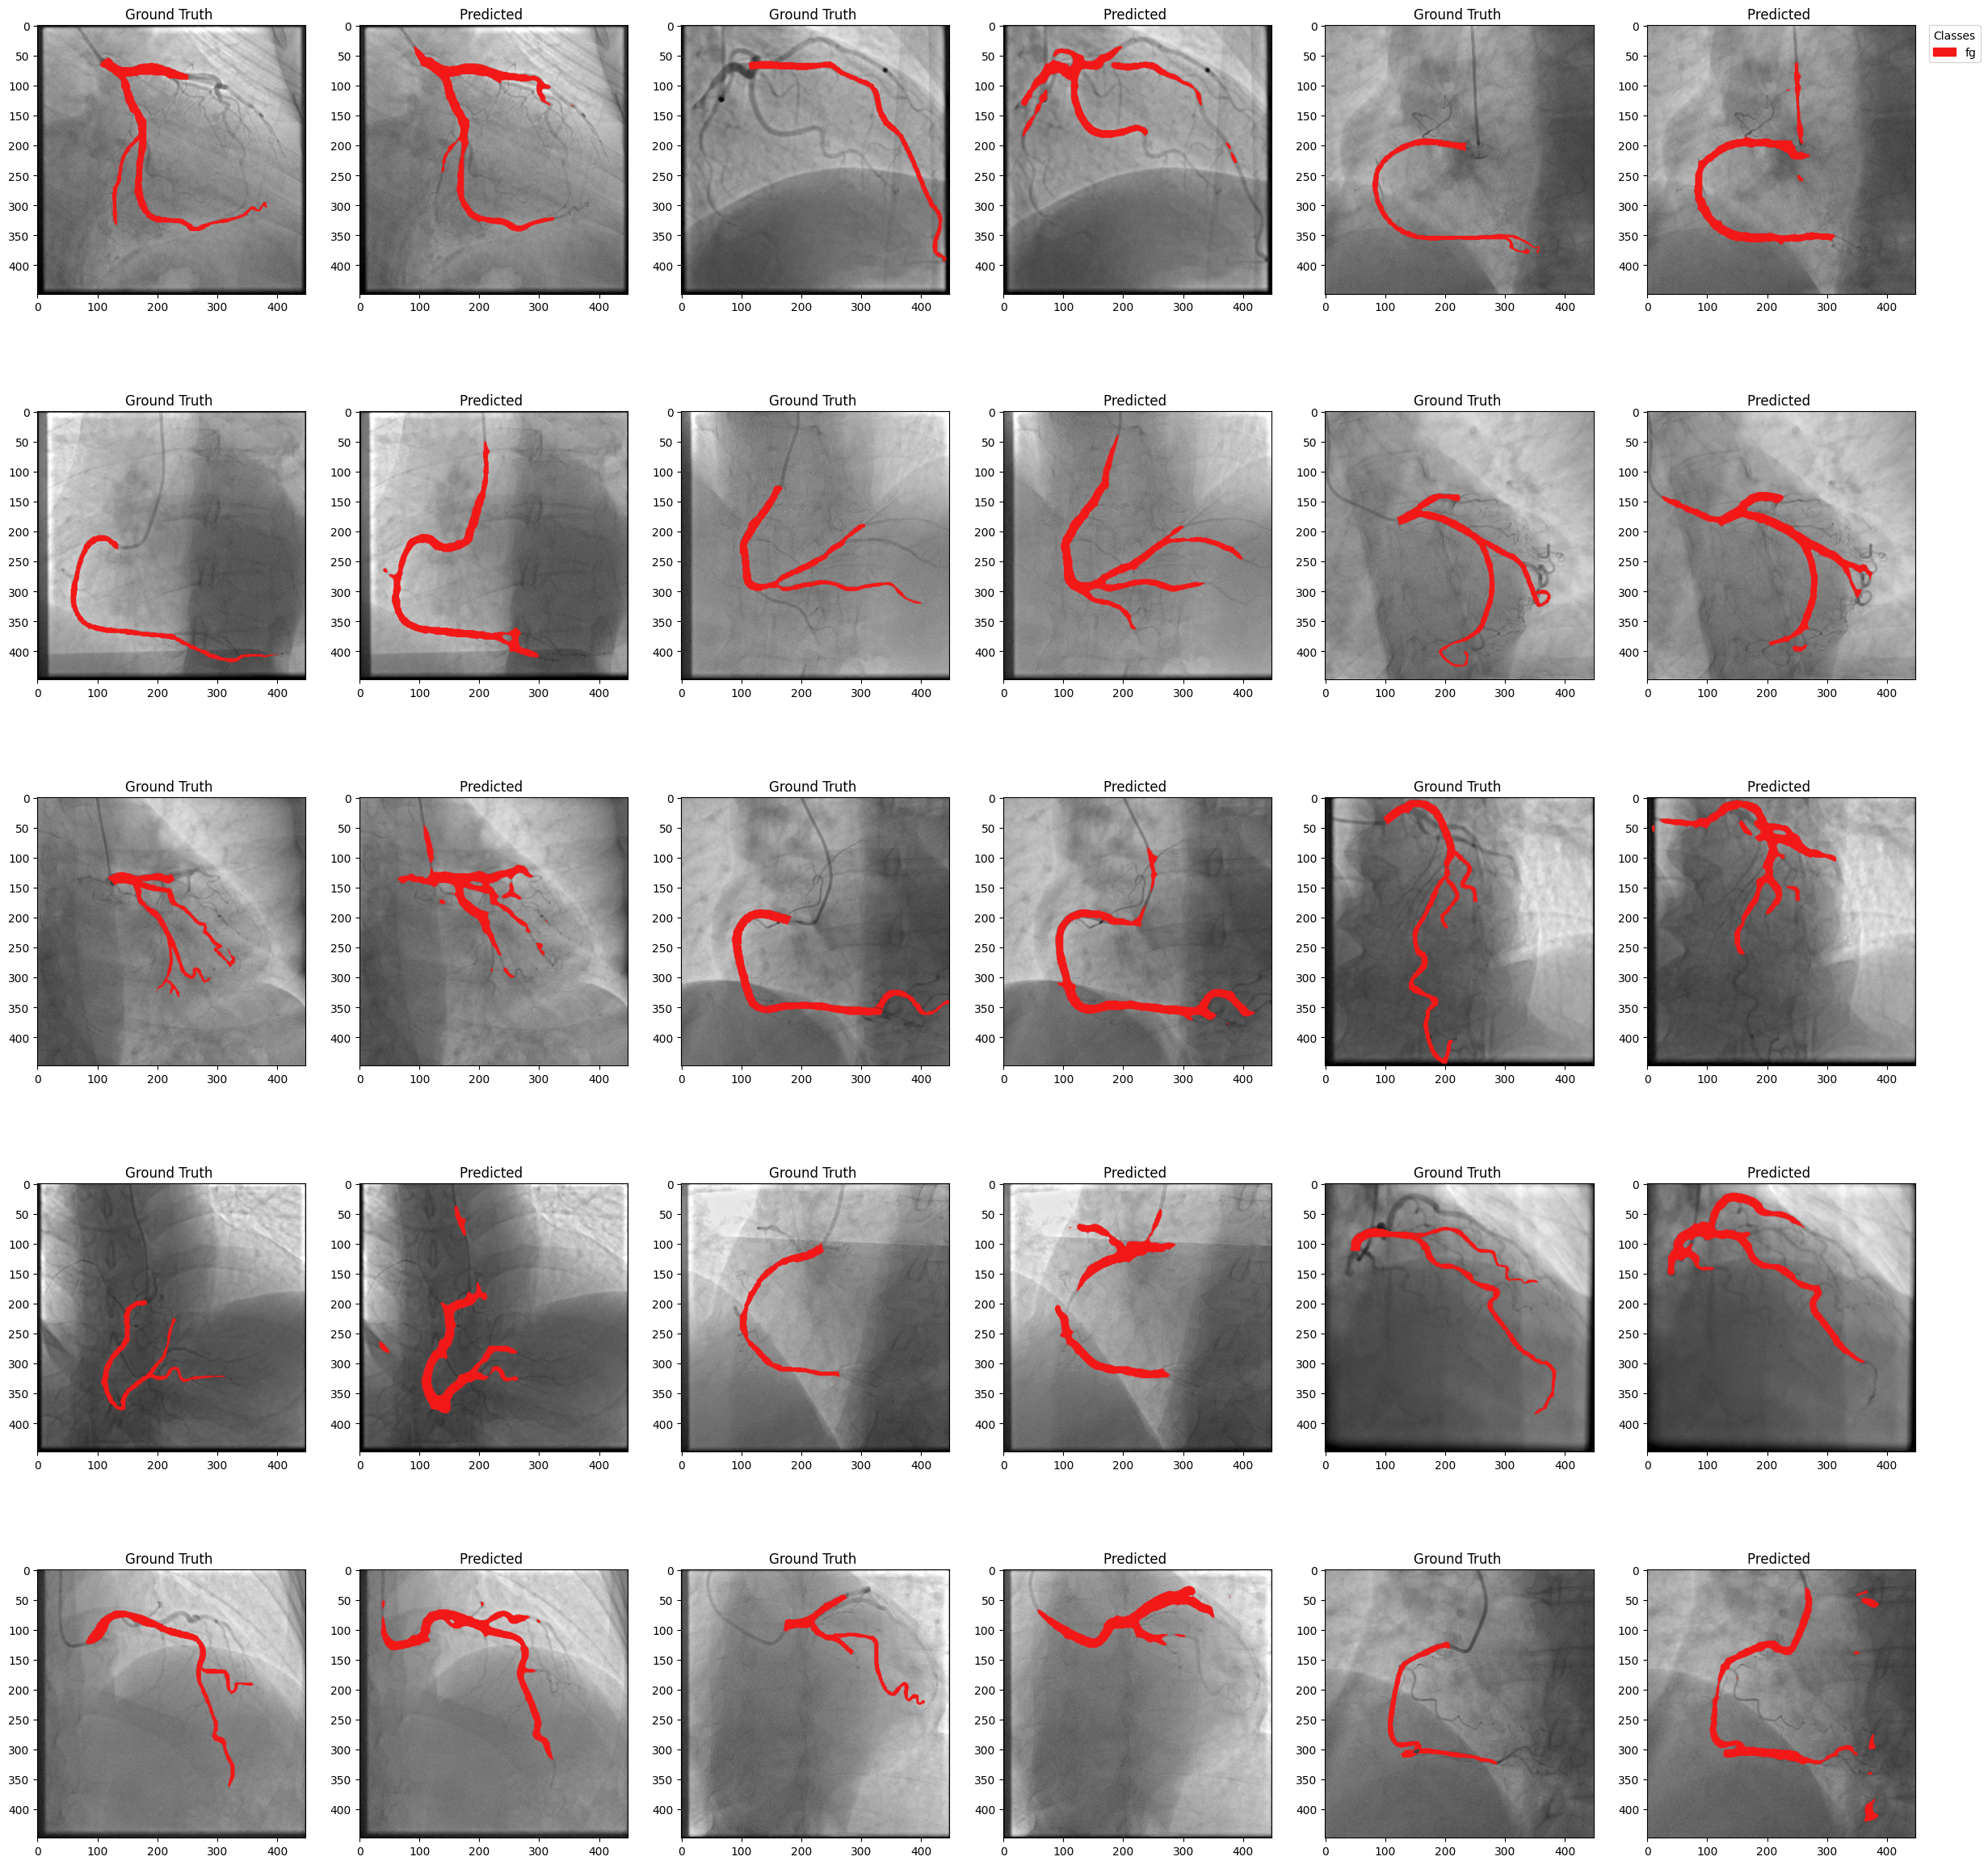

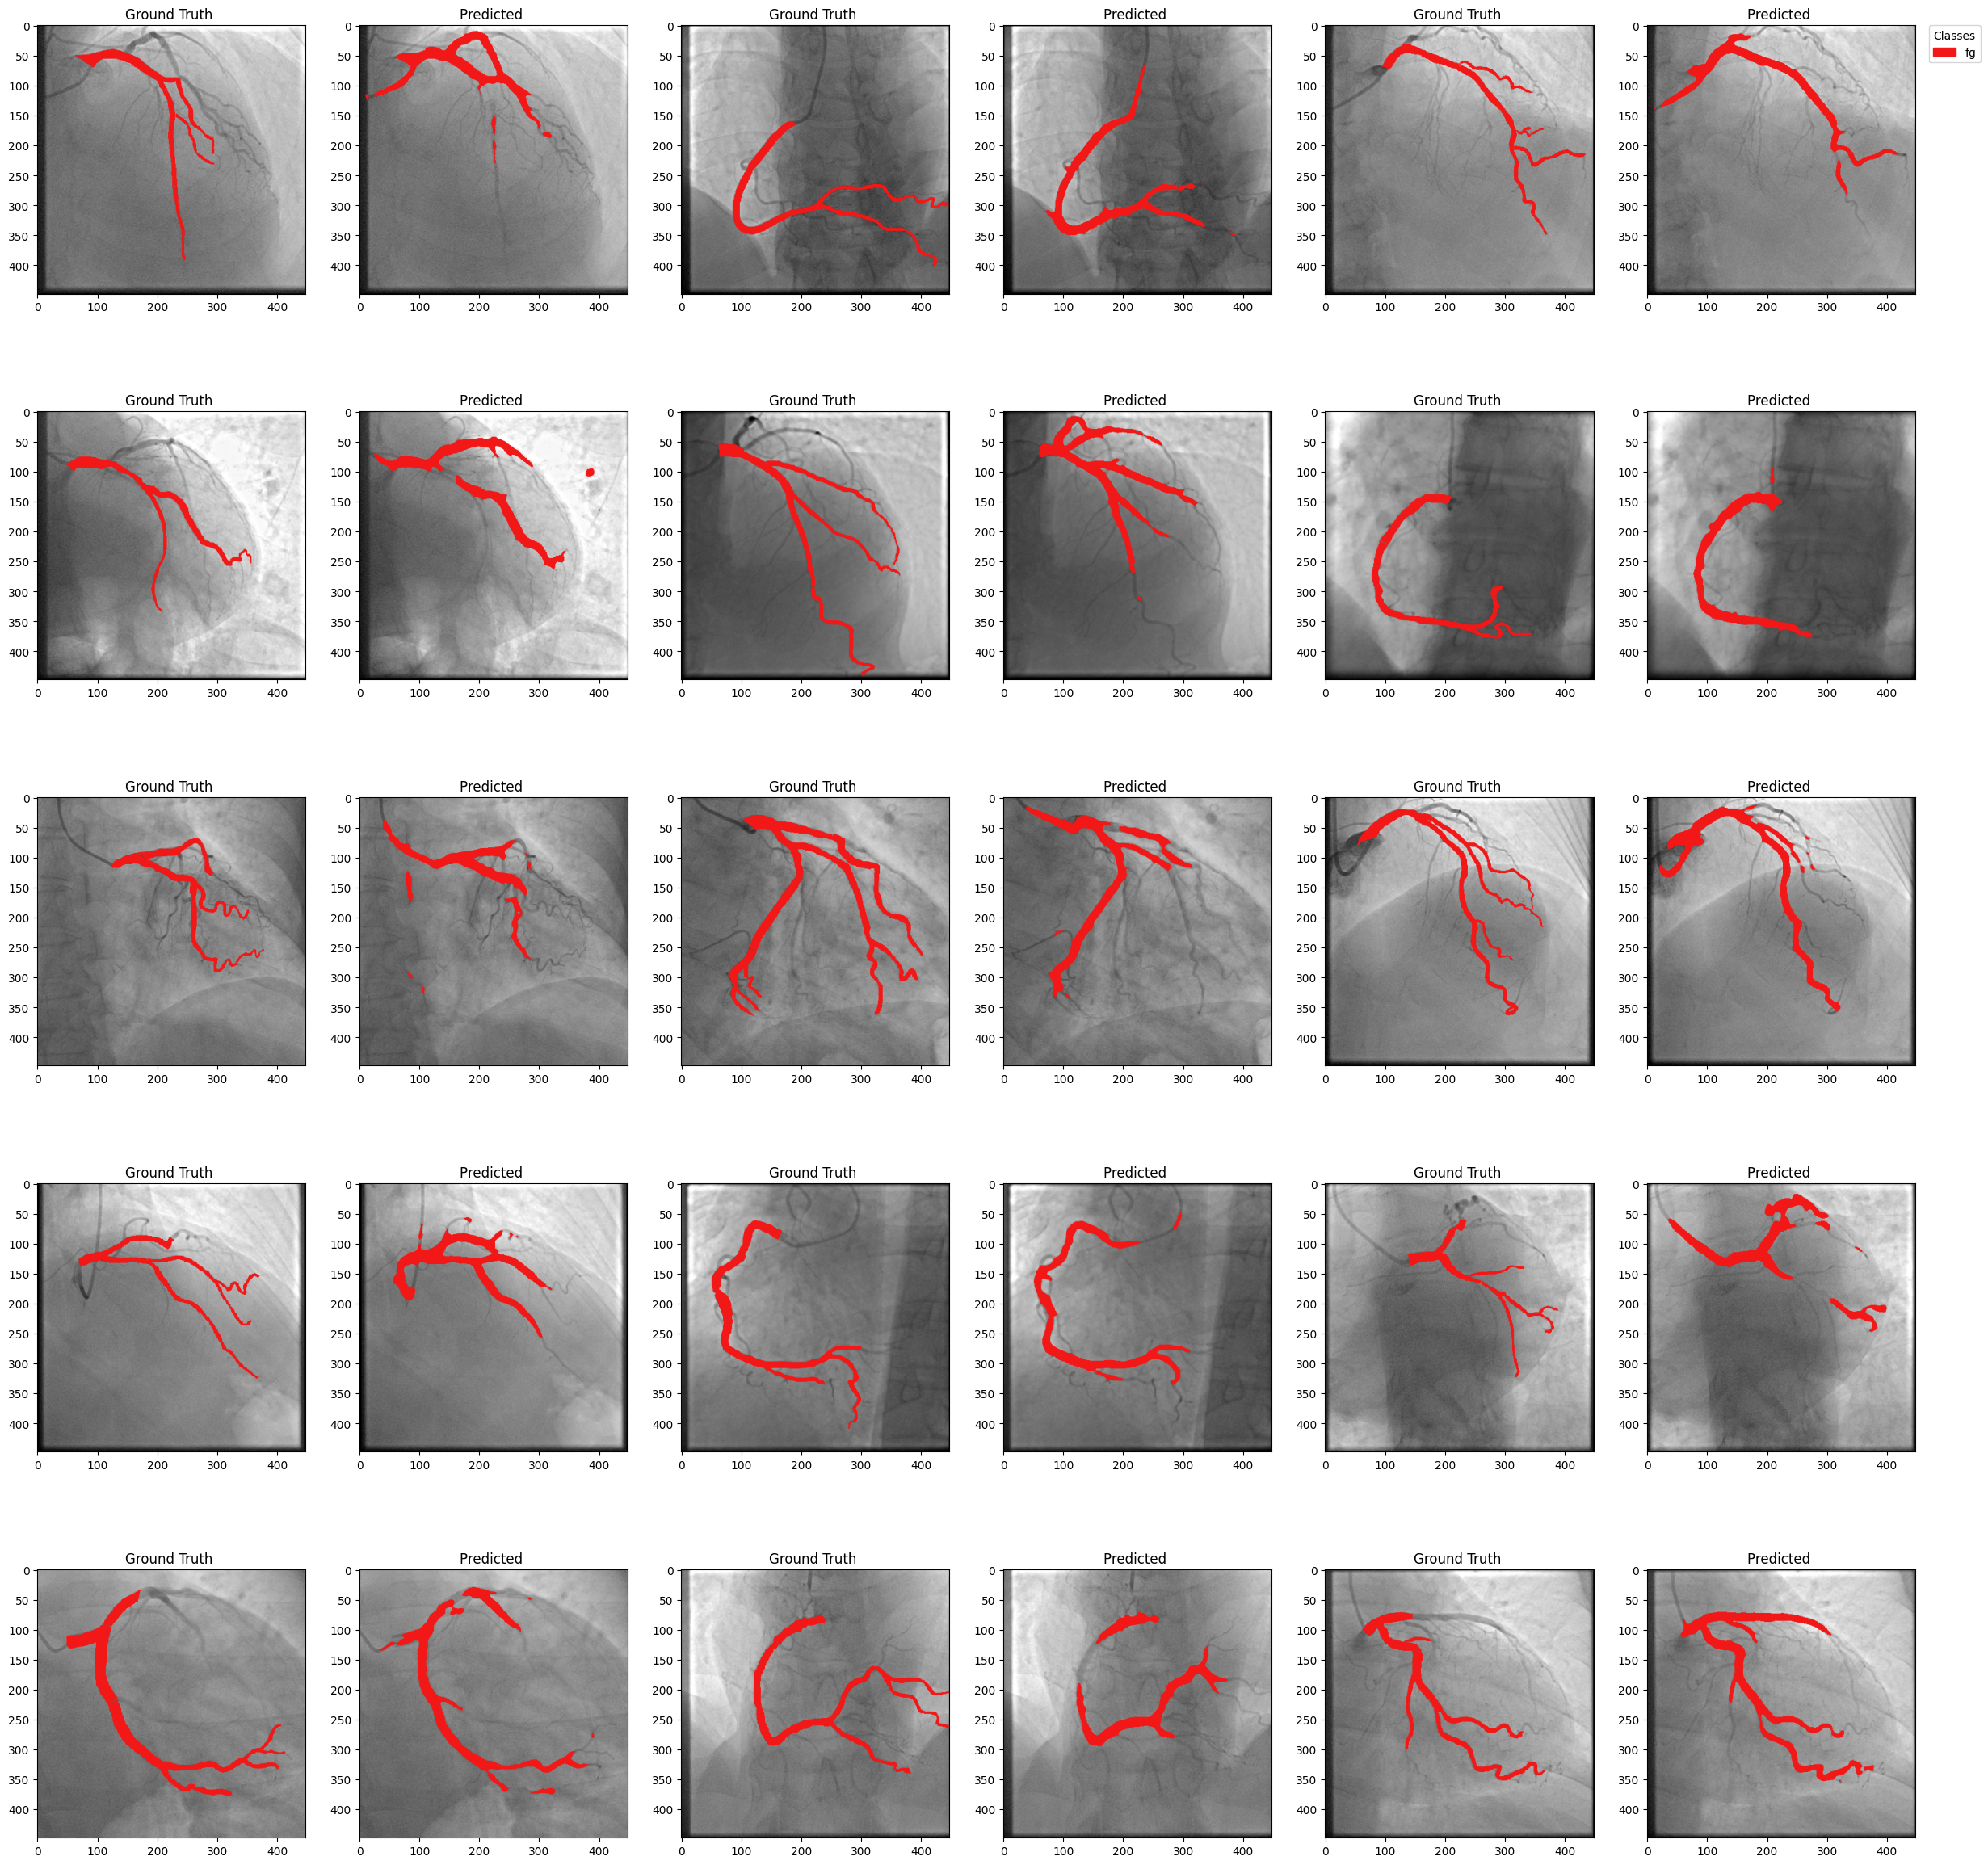

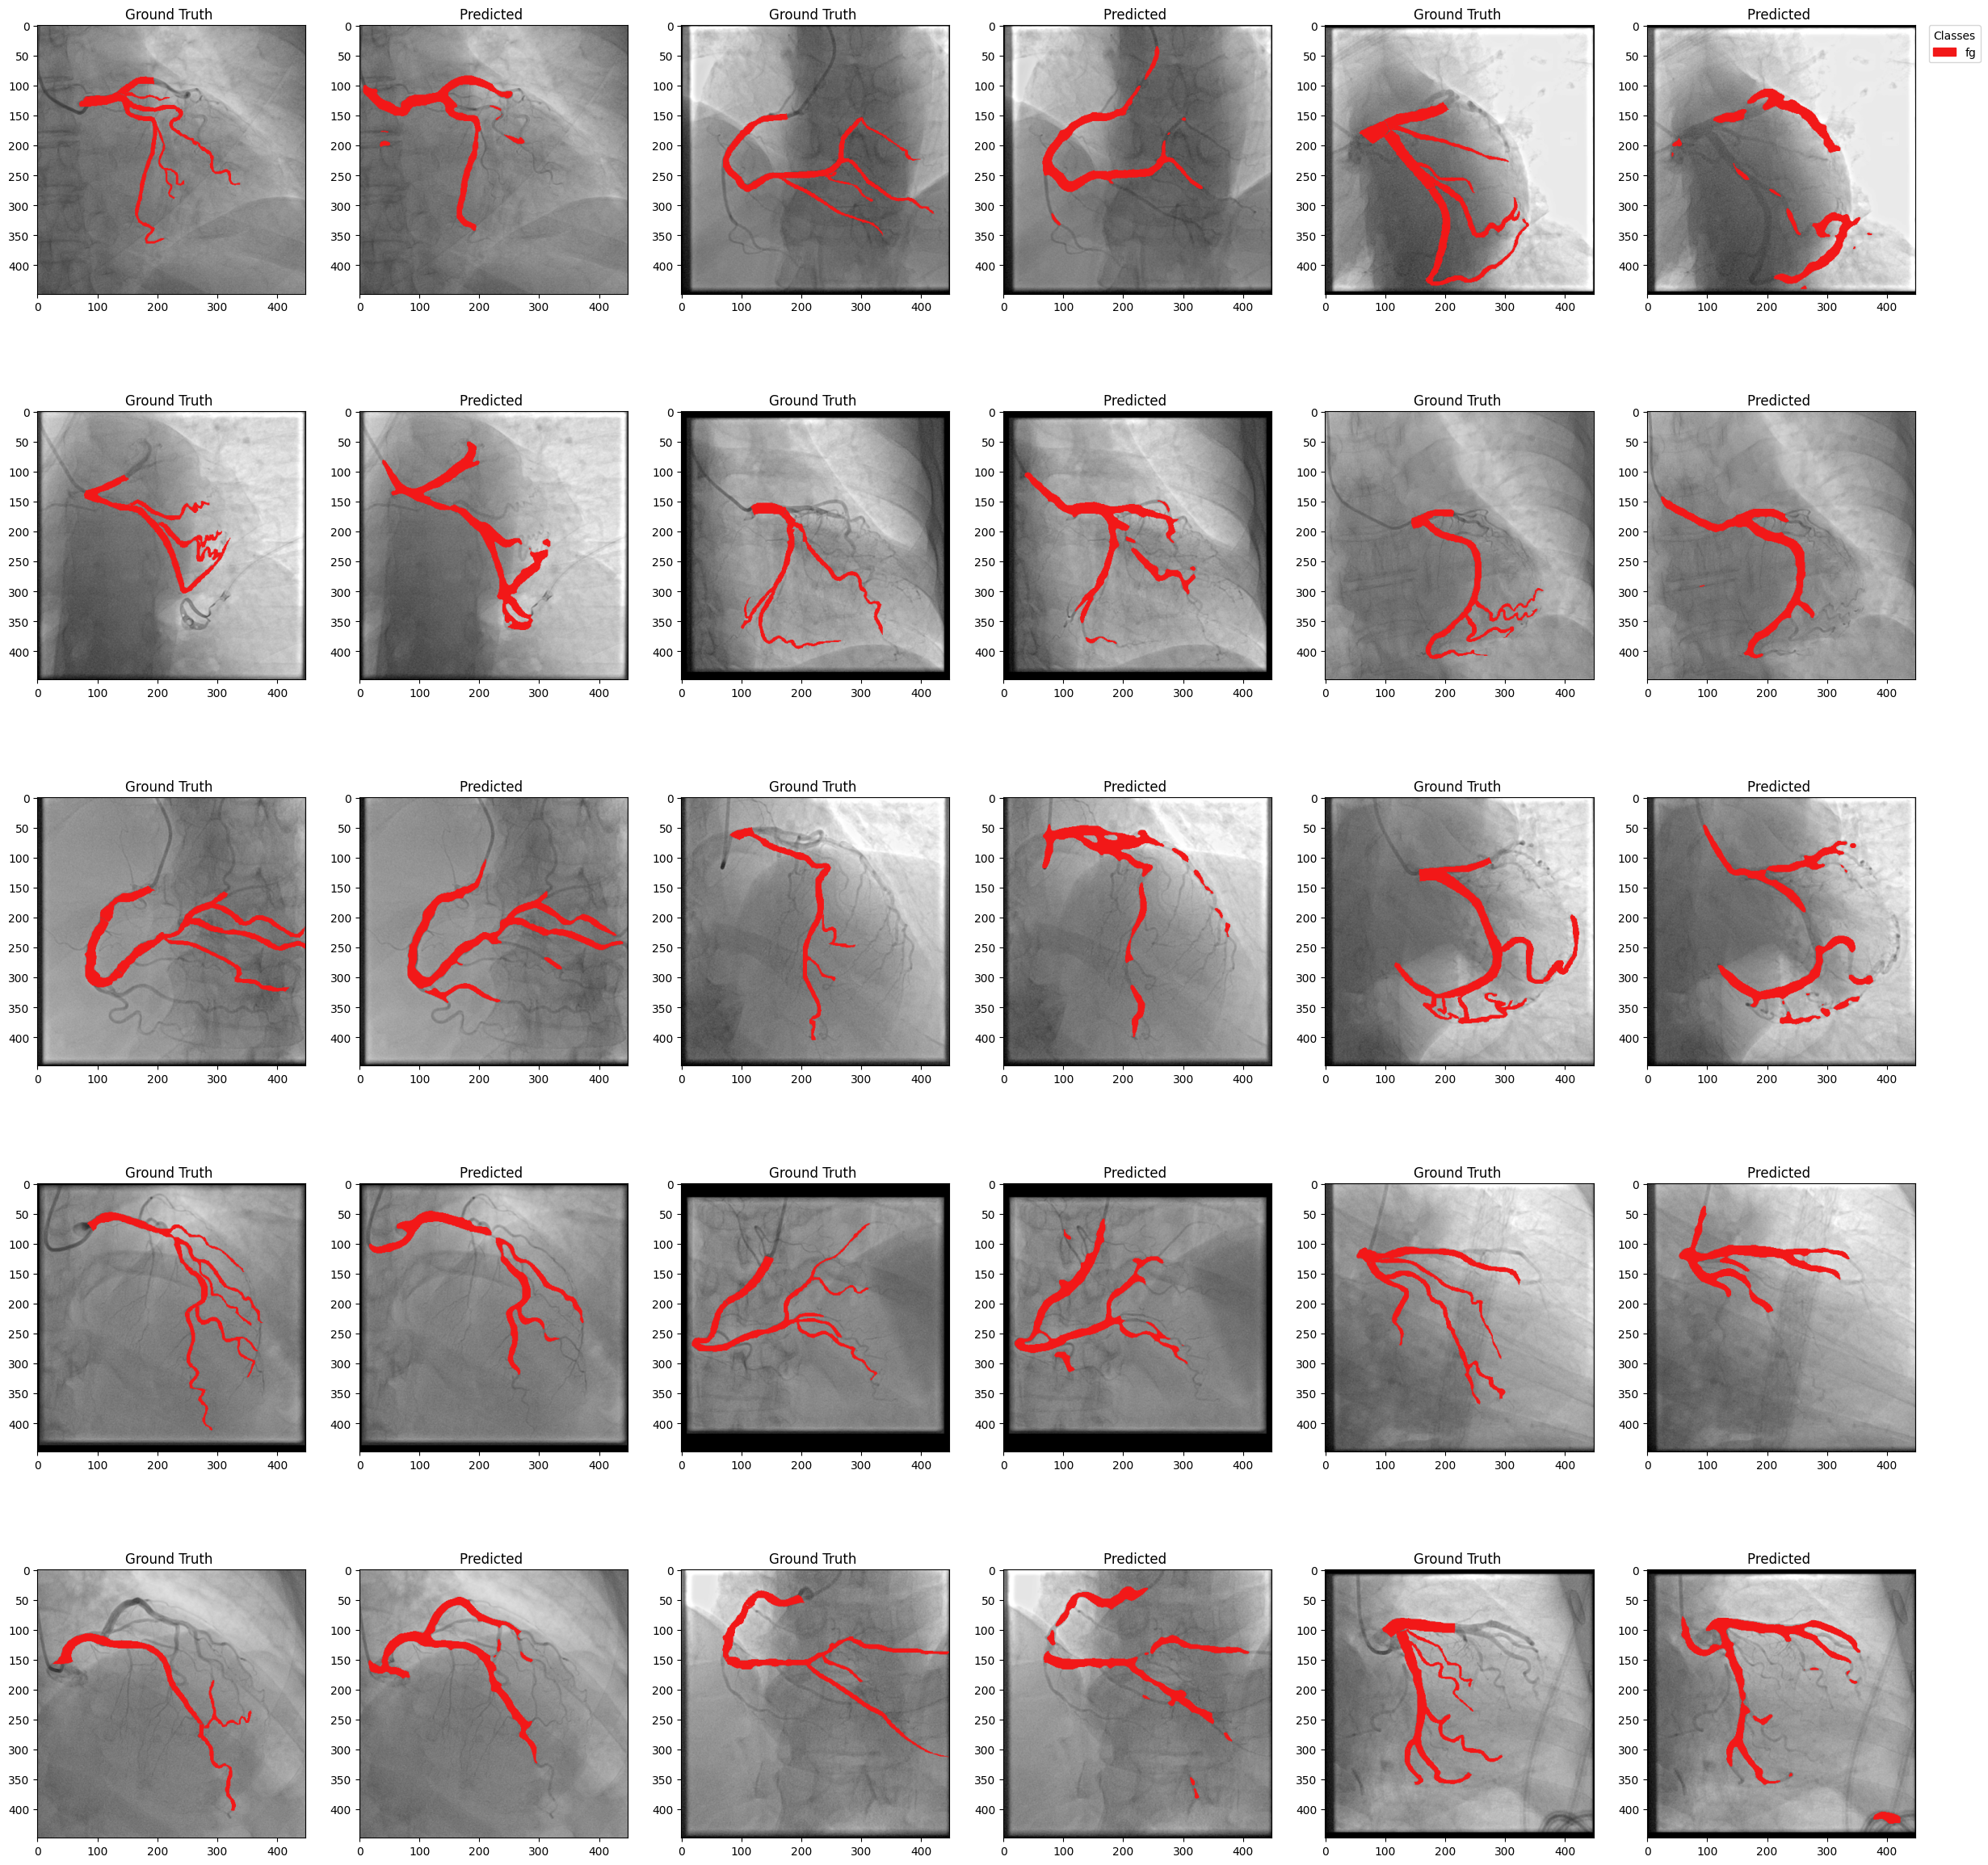

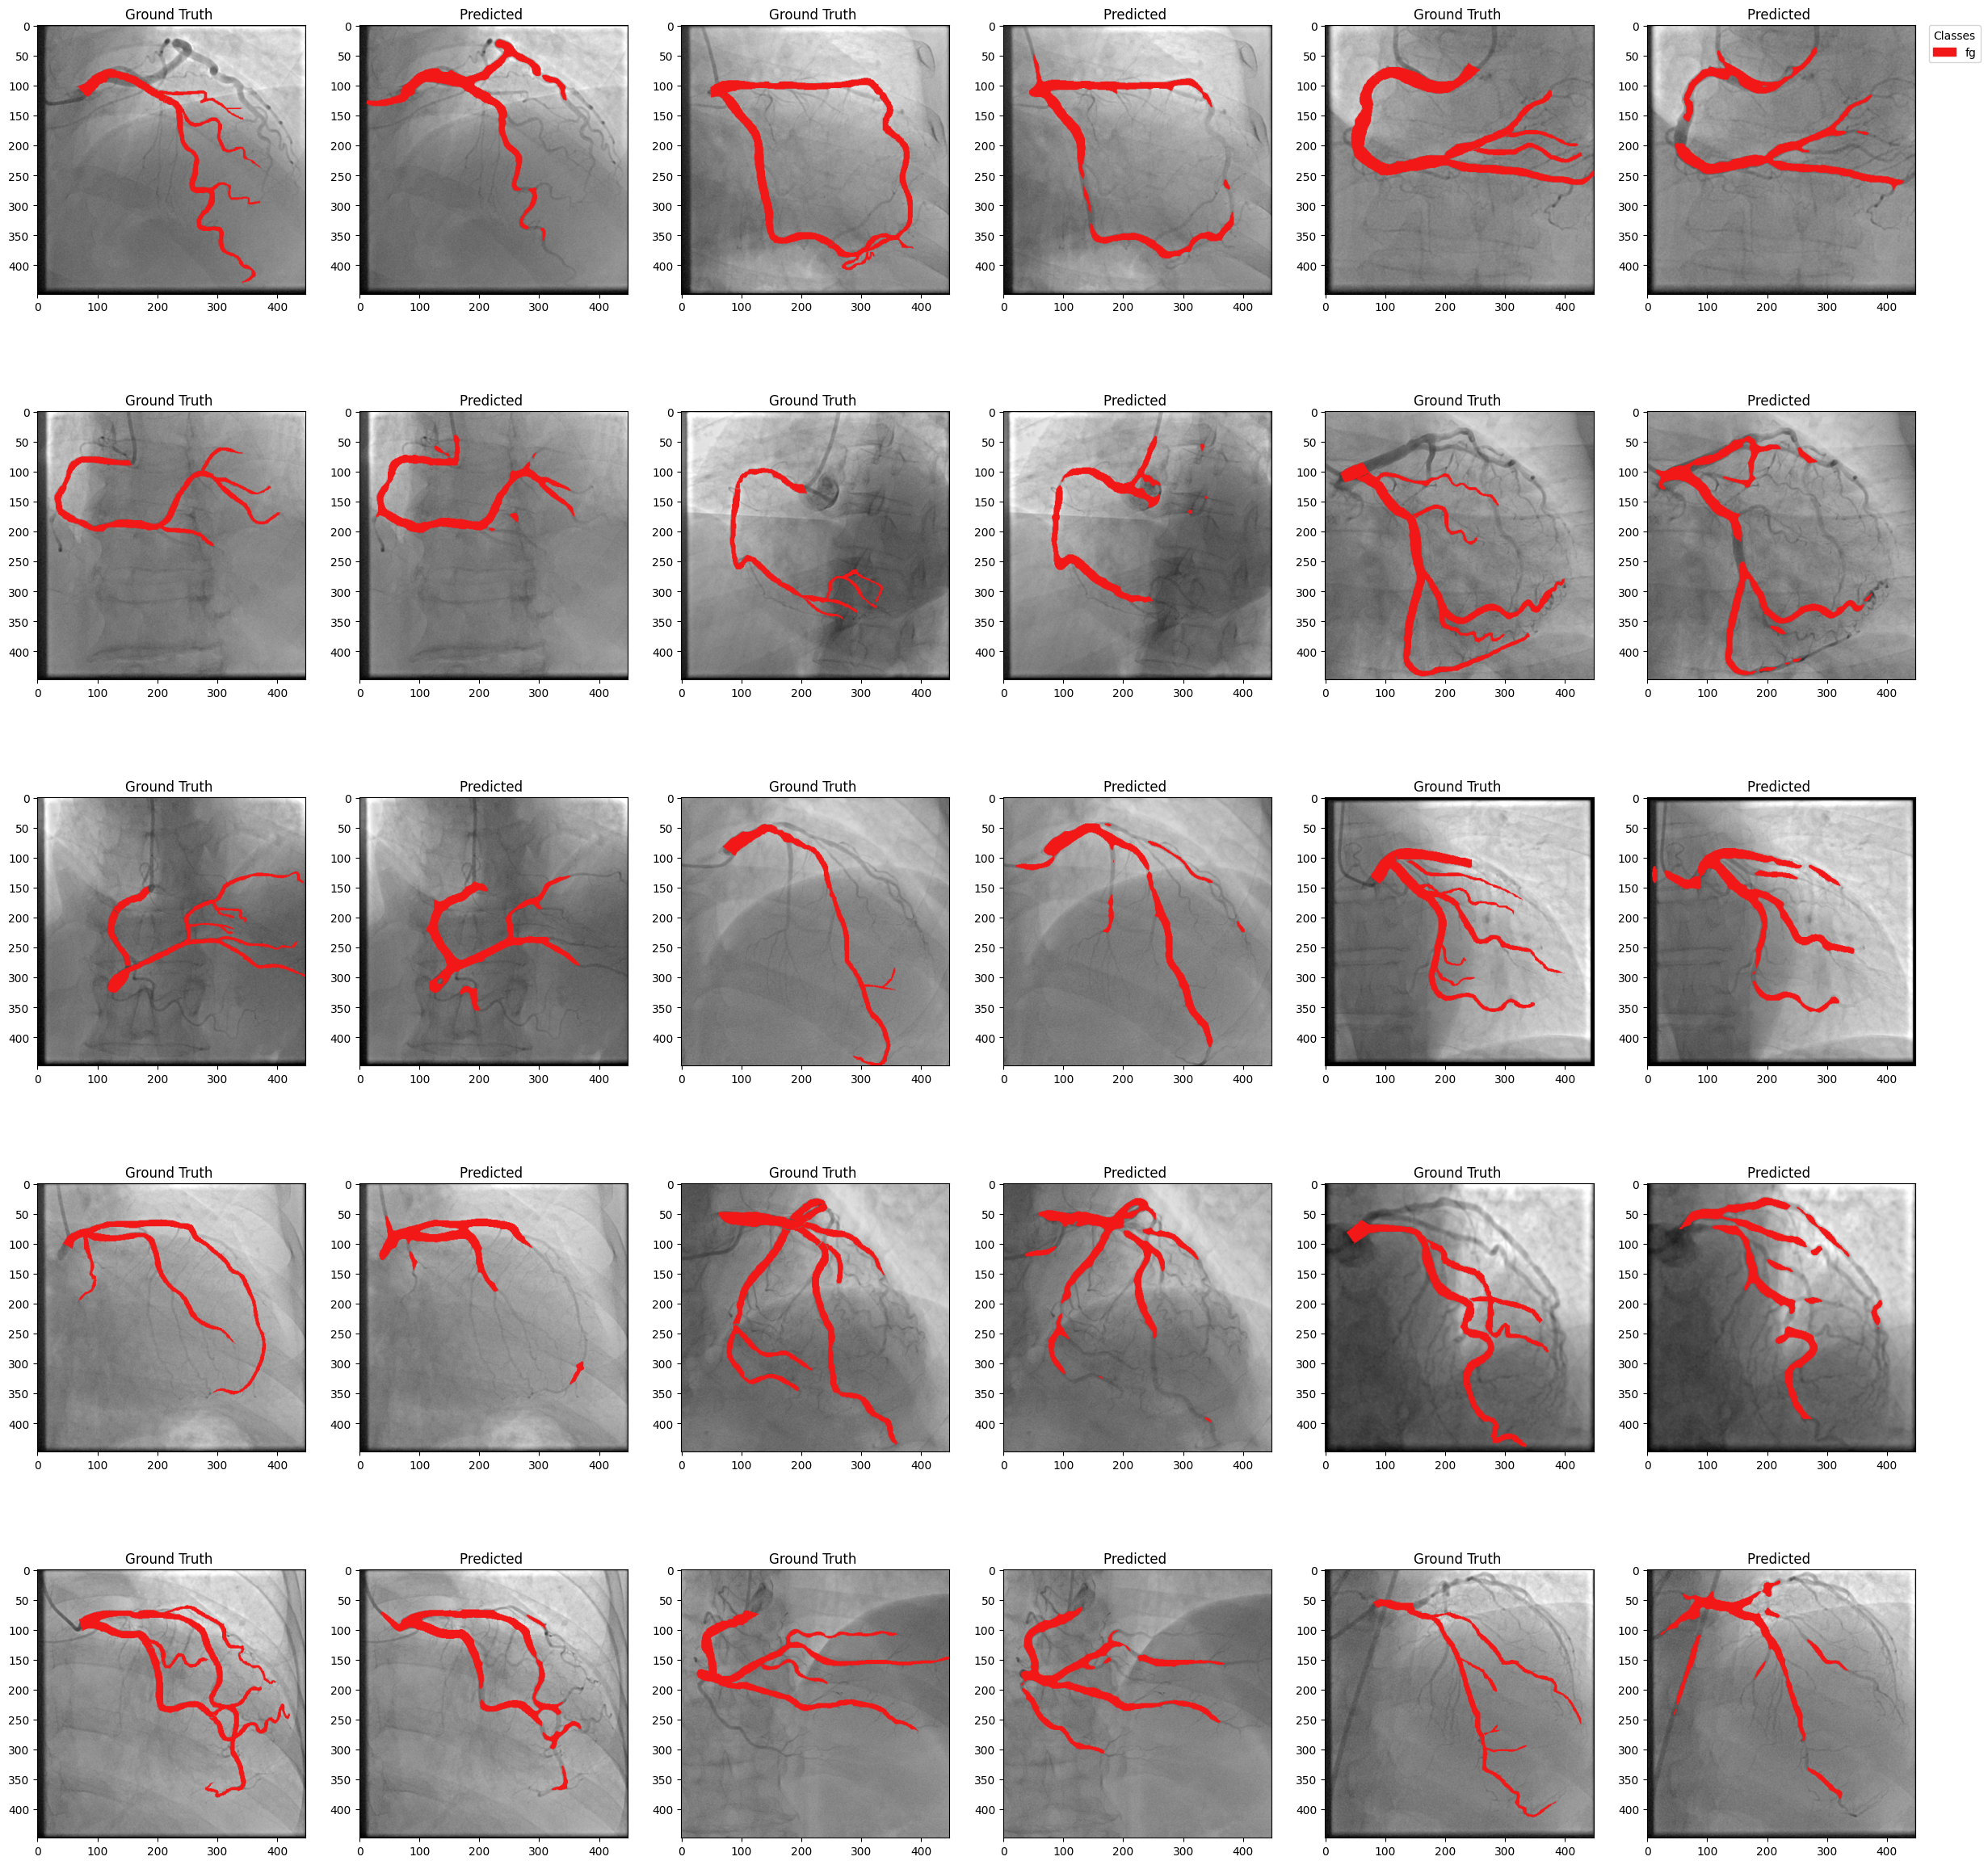

In [ ]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    normalizer = normalizer,
    args=args,
    class_map=class_map,
    name=args["name"],
    valid_images = valid_images,
    test_transforms = test_transforms,
    notebook_name = "Multi_Main.ipynb",
    class_count = args["class_count"],
    device = args["device"],
    training_mode = args["training_mode"]
)